# Unsupervised Clustering - Phone Segmentation
- Elbow curve & Silhouette scores
- KMeans clustering
- PCA visualization
- Brand dominance per cluster

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

In [10]:
# Load data
print("Loading cleaned dataset...")
df = pd.read_csv('phones_cleaned_imputed.csv')
print(f"Shape: {df.shape}\n")

# Create Value_Score if missing
if 'Value_Score' not in df.columns:
    df['Value_Score'] = (df['RAM_GB'] * df['Battery_mAh']) / df['Price_INR']
    print("Created Value_Score\n")

Loading cleaned dataset...
Shape: (1532, 13)

Created Value_Score



In [11]:
# ============================================================
# CLUSTERING
# ============================================================
print("=" * 60)
print("CLUSTERING: PHONE SEGMENTATION")
print("=" * 60)

cluster_features = ['Price_INR', 'RAM_GB', 'Battery_mAh', 'Rear_Camera_MP', 'Rating', 'Value_Score']
df_cluster = df[cluster_features].dropna()

# 1. Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

CLUSTERING: PHONE SEGMENTATION



Finding optimal k...
  k=2: Inertia=6637, Silhouette=0.3289
  k=3: Inertia=5227, Silhouette=0.3302
  k=4: Inertia=4390, Silhouette=0.2849
  k=5: Inertia=3760, Silhouette=0.2750
  k=6: Inertia=3377, Silhouette=0.2809
  k=7: Inertia=3057, Silhouette=0.2817
  k=8: Inertia=2746, Silhouette=0.2659


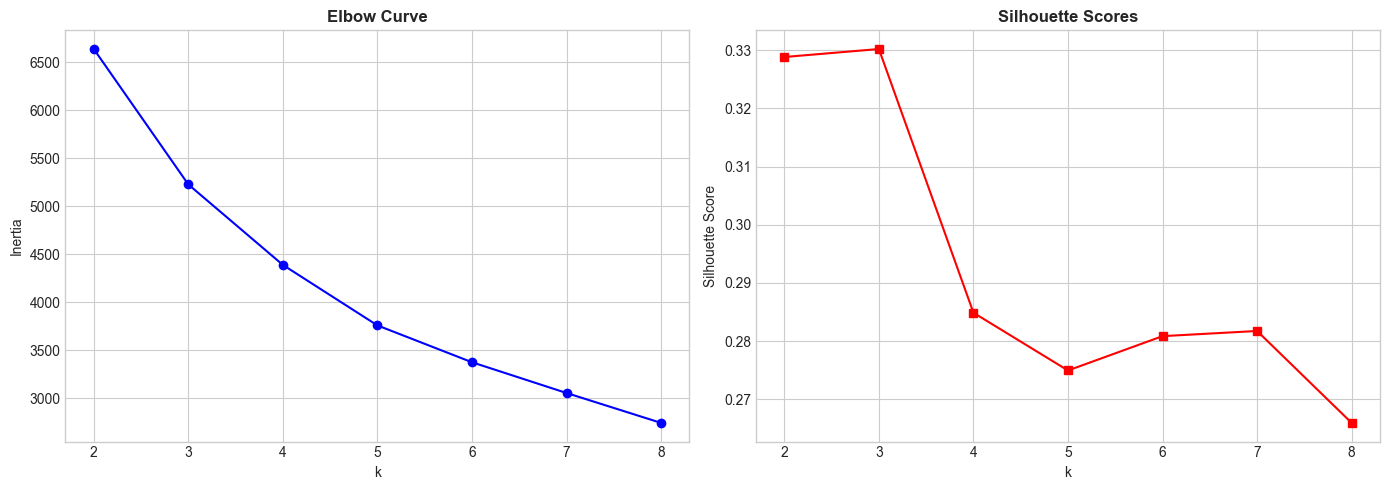

Saved: plots/clustering_elbow.png

Best k (by silhouette): 3


In [12]:
# 2. Find optimal k
print("\nFinding optimal k...")
inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouettes.append(sil)
    print(f"  k={k}: Inertia={km.inertia_:.0f}, Silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_title('Elbow Curve', fontweight='bold')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[1].plot(K_range, silhouettes, 'rs-')
axes[1].set_title('Silhouette Scores', fontweight='bold')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.savefig('plots/clustering_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/clustering_elbow.png\n")

best_k = K_range[np.argmax(silhouettes)]
print(f"Best k (by silhouette): {best_k}")

In [13]:
# 3. Apply KMeans
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)

# 4. Label clusters based on centroids
centroid_df = pd.DataFrame(kmeans.cluster_centers_, columns=cluster_features)
centroid_df['Cluster'] = range(best_k)

print("\nCluster Centroids:")
print(centroid_df.round(2).to_string(index=False))

labels_map = {}
for i in range(best_k):
    centroid = centroid_df.iloc[i]
    if centroid['Price_INR'] < centroid_df['Price_INR'].mean():
        if centroid['Value_Score'] > centroid_df['Value_Score'].mean():
            labels_map[i] = 'Value King'
        else:
            labels_map[i] = 'Budget Workhorse'
    elif centroid['Rear_Camera_MP'] > centroid_df['Rear_Camera_MP'].mean():
        labels_map[i] = 'Camera Champion'
    elif centroid['RAM_GB'] > centroid_df['RAM_GB'].mean():
        labels_map[i] = 'Power User Pick'
    else:
        labels_map[i] = 'All-Rounder'

for i in range(best_k):
    if i not in labels_map:
        labels_map[i] = f'Segment {i + 1}'

df_cluster['Cluster_Label'] = df_cluster['Cluster'].map(labels_map)
print(f"\nCluster Labels: {labels_map}")

# 5. Cluster summary
print("\nCluster Summary:")
print(df_cluster.groupby('Cluster_Label')[cluster_features].mean().round(2).to_string())


Cluster Centroids:
 Price_INR  RAM_GB  Battery_mAh  Rear_Camera_MP  Rating  Value_Score  Cluster
      0.13    1.07         0.16            0.80    0.30         1.02        0
     -0.19   -0.61        -0.07           -0.44   -0.17        -0.53        1
     11.44    3.15        -1.33            0.35    0.35        -1.97        2

Cluster Labels: {0: 'Value King', 1: 'Budget Workhorse', 2: 'Camera Champion'}

Cluster Summary:
                  Price_INR  RAM_GB  Battery_mAh  Rear_Camera_MP  Rating  Value_Score
Cluster_Label                                                                        
Budget Workhorse    7724.83    3.44      5188.27           26.66    4.02         2.33
Camera Champion    53299.00   10.40      4480.00           50.00    4.18         0.87
Value King          8978.02    6.56      5317.98           63.46    4.17         3.91


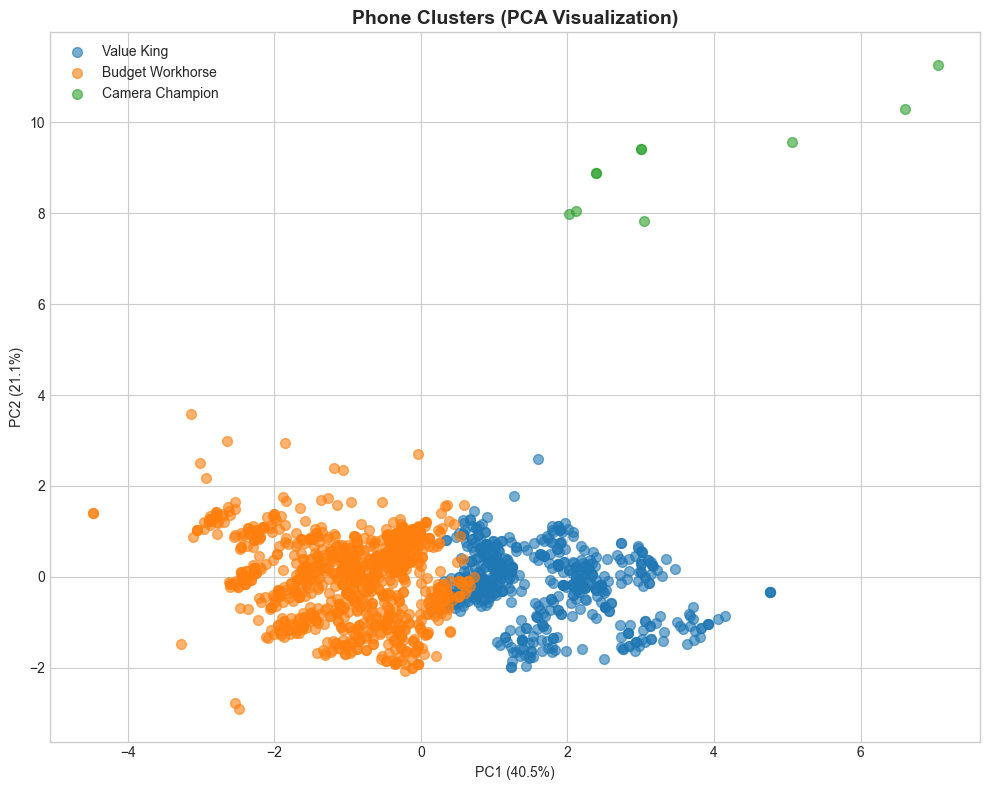

Saved: plots/clusters_pca.png



In [14]:
# 6. PCA visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_cluster['PC1'] = X_pca[:, 0]
df_cluster['PC2'] = X_pca[:, 1]

plt.figure(figsize=(10, 8))
for label in df_cluster['Cluster_Label'].unique():
    subset = df_cluster[df_cluster['Cluster_Label'] == label]
    plt.scatter(subset['PC1'], subset['PC2'], label=label, alpha=0.6, s=50)
plt.title('Phone Clusters (PCA Visualization)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)')
plt.legend()
plt.tight_layout()
plt.savefig('plots/clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/clusters_pca.png\n")

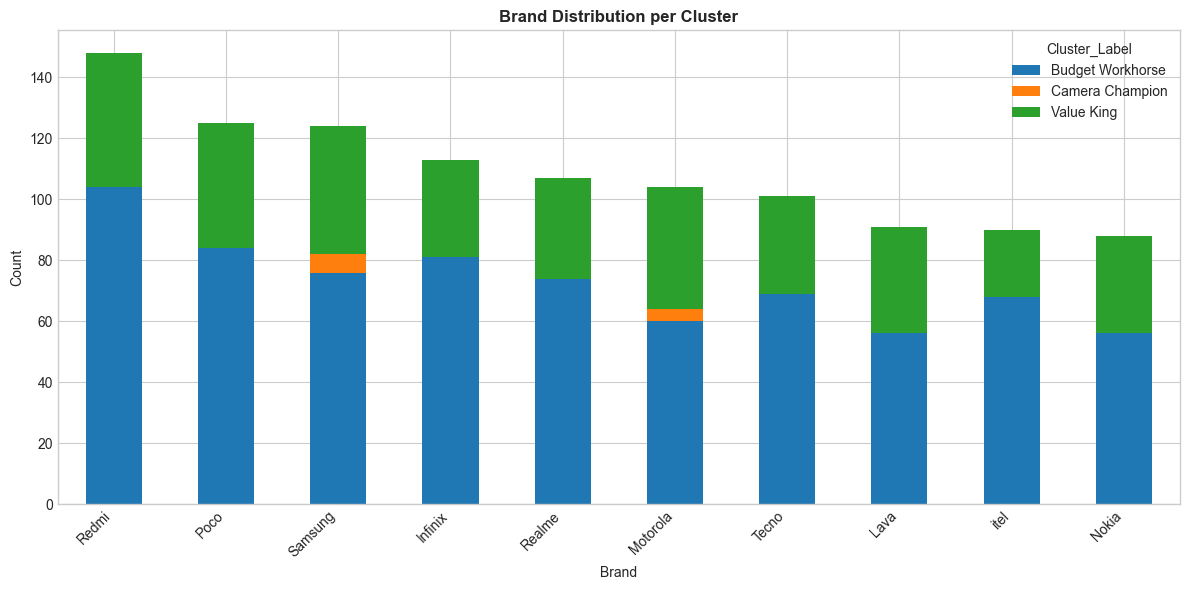

Saved: plots/brand_cluster.png



In [15]:
# 7. Brand dominance per cluster
df_cluster_with_brand = df_cluster.copy()
df_cluster_with_brand['Brand'] = df.loc[df_cluster.index, 'Brand']

brand_cluster = pd.crosstab(df_cluster_with_brand['Brand'], df_cluster_with_brand['Cluster_Label'])
top_brands_clust = brand_cluster.sum(axis=1).sort_values(ascending=False).head(10).index
brand_cluster_top = brand_cluster.loc[top_brands_clust]

brand_cluster_top.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Brand Distribution per Cluster', fontweight='bold')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plots/brand_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/brand_cluster.png\n")

In [16]:
# 8. Save clustered dataset
df.loc[df_cluster.index, 'Cluster'] = df_cluster['Cluster'].values
df.loc[df_cluster.index, 'Cluster_Label'] = df_cluster['Cluster_Label'].values
df.to_csv('phones_clustered.csv', index=False)
print(f"Saved: phones_clustered.csv")
print(f"Shape: {df.shape}")
print("\nClustering Complete!")

Saved: phones_clustered.csv
Shape: (1532, 16)

Clustering Complete!
